# CNN Deconv Topological studies

Study the performance of NEXT classical toplogocal method using data previously deconvoluted bu Martin's CNN

25/11/24 Santiago

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

In [52]:
import glob
import sys
from os import listdir
from collections import namedtuple
import itertools as itertools

In [53]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize
import networkx as nx

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [20]:
pypaths = ('/home/usc/ie/jhm/NEXT/nextana',
           '/home/usc/ie/jhm/NEXT/hipy', 
           '/home/usc/ie/jjhm/NEXT/IC')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [21]:
import hipy.utils        as ut
#import hipy.histos       as histos
import hipy.pltext       as pltext
#import hipy.profile      as prof
#from invisible_cities.io.dst_io import load_dst, load_dsts
from hipy.styles import style
style()

## Load data


In [22]:
datafilename = 'dataset_15607_DEP_deco.h5'
mcfilename   = 'dataset_4bar_MC_DEP_deco.h5'
datapath     = '/mnt/netapp1/Store_next_data/NEXT100/deco_seg/'

In [23]:
ifilename = datapath + datafilename
print(f'loading {ifilename}')
data     =  pd.read_hdf(ifilename, 'DATASET/Voxels');
bin_info =  pd.read_hdf(ifilename, 'DATASET/BinsInfo');

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_15607_DEP_deco.h5


In [45]:
def get_coors(data, bin_info = bin_info):
    """Get the coordinates from binned data and bin info."""
    coors = [bin_info['min_'+x].values + data[x+'bin'].values * bin_info['size_'+x].values for x in ('x', 'y', 'z')] 
    return coors

bin_widths = [bin_info['size_'+x].values for x in ('x', 'y', 'z')]

def get_bins(coors, bin_widths = (1, 1, 1)):
    """Get the bins for each coordinate given the bin widths."""
    bins = [np.arange(np.min(coor) - 3*width/2, np.max(coor) + 3*width/2, width) for coor, width in zip(coors, bin_widths)]
    return bins

def event_display(coors, bins, ene = None):
    """Display a 2D histogram of the event given the coordinates and bin width."""
    cmap = 'plasma' # 'viridis', 'cividis', 'plasma'
    cv   = pltext.canvas(4, 2)
    bins = get_bins(coors, bin_widths)
    clabel = 'counts' if ene is None else 'energy (keV)'
    ene    = ene if ene is not None else np.ones_like(coors[0])
    labels = ['X', 'Y', 'Z']
    for k, coor in enumerate(((0, 1), (2, 1), (0, 2))):
        i, j = coor
        cv(k+1); plt.hist2d(coors[i], coors[j], weights = ene, bins = (bins[i], bins[j]), cmap = cmap);
        xl, yl = labels[i], labels[j]
        plt.xlabel(xl); plt.ylabel(yl); plt.title(xl+yl+' projection'); plt.colorbar(label = clabel)
    plt.tight_layout()
    return cv


In [215]:
def convert_to_graph(coors, bins, ene, ene_threshold = 0, nsides = 1):
    """Convert binned data to a graph representation."""

    h3d, _ = np.histogramdd(coors, bins = bins, weights = ene)

    voxels  = h3d > ene_threshold
    indices = np.argwhere(voxels > ene_threshold)
    nx_bins, ny_bins, nz_bins = h3d.shape

    cube_index = list(itertools.product([-1, 0, 1], repeat=3))
    cube_index = [cube_id for cube_id in cube_index if np.sum(np.abs(cube_id)) <= nsides]
    print(cube_index)

    def in_range(i, j, k):
        return  (0 <= i < nx_bins) and (0 <= j < ny_bins) and (0 <= k < nz_bins)
 
    graph = nx.Graph()

    for i, j, k in indices:
        graph.add_node((i, j, k), weight = h3d[i, j, k])
        
        for di, dj, dk in cube_index:
            ni, nj, nk = i + di, j + dj, k + dk
            if in_range(ni, nj, nk):
                if voxels[ni, nj, nk]:
                    graph.add_edge((i, j, k), (ni, nj, nk))

    return graph
    

In [188]:
def graph_extremes(graph):
    # Start from an arbitrary node
    start = next(iter(graph.nodes()))
    
    # 1) find the farthest node from start
    dist_start = nx.single_source_shortest_path_length(graph, start)
    u = max(dist_start, key=dist_start.get)
    
    # 2) from that farthest node, find its farthest partner
    dist_u = nx.single_source_shortest_path_length(graph, u)
    v = max(dist_u, key=dist_u.get)
    
    # Return the extremes and the distance
    return u, v, dist_u[v]

# graph: tu grafo
def graph_connectivity(graph):

    print("Is graph conected? ", nx.is_connected(graph))
    components = list(nx.connected_components(graph))
    print(f"Number of components: {len(components)}")
    for i, comp in enumerate(components, 1):
        print(f"Component {i}: {comp}")

    largest_component_nodes = max(components, key=len)
    largest_component = graph.subgraph(largest_component_nodes).copy()
    return components, largest_component

In [189]:
def display_graph(graph):
    cmap = 'plasma' # 'viridis', 'cividis', 'plasma'
    plt.figure(figsize=(6,6))

    weights = nx.get_node_attributes(graph, "weight")
    node_colors = list(weights.values())
    node_sizes  = [w * 20 for w in node_colors]  # escala ajustable
    #node_sizes =  200 * node_sizes/np.max(node_sizes) 

    # Posiciones del grafo
    pos = nx.kamada_kawai_layout(graph)
    #pos = nx.spring_layout(graph, seed = 0)


    # Draw edges with alpha
    nx.draw_networkx_edges(graph, pos, alpha = 0.1, width = 1, edge_color="black")
    # Draw nodes
    nx.draw_networkx_nodes(graph, pos, node_size = node_sizes, node_color =node_colors, cmap=plt.cm.viridis, alpha = 0.5)

    u, v, dist = graph_extremes(graph)
    extremes = (u, v)
    xs = [pos[n][0] for n in extremes]
    ys = [pos[n][1] for n in extremes]
    plt.scatter(xs, ys, s = 400, c = 'red', marker = 'x', linewidths = 3, label = 'Extremos')

    #plt.gca().set_aspect("equal")
    plt.show()

    return extremes, dist

## Display an event

In [129]:
dataevts = data.groupby('dataset_id')

In [218]:
evt = dataevts.get_group(22)

In [219]:
#evt.head()

In [220]:
coors = get_coors(evt)
ene   = 1e3* evt.energy.values 
bins  = get_bins(coors, bin_widths)

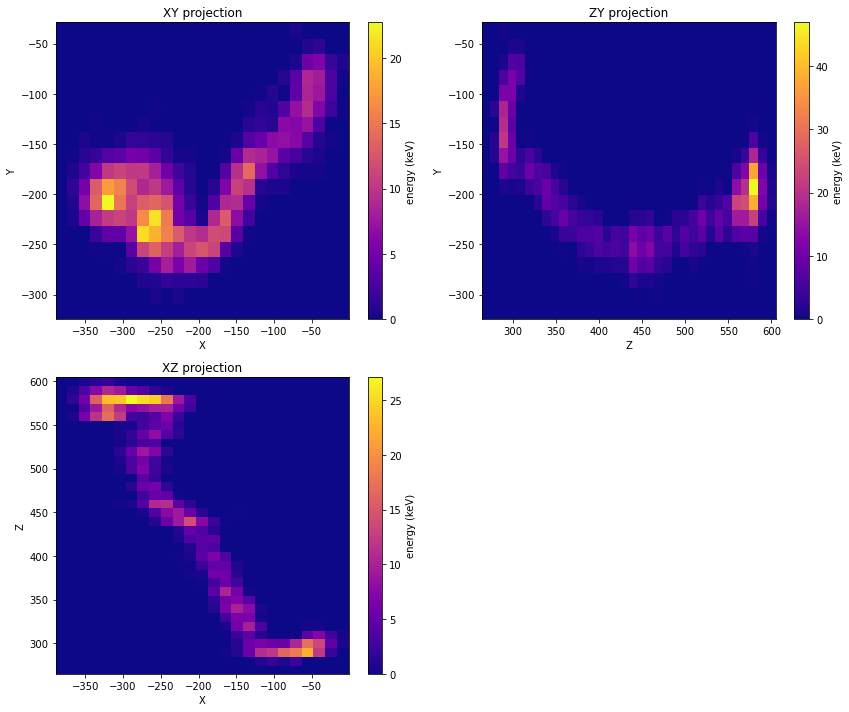

In [221]:
event_display(coors, bins, ene = ene);

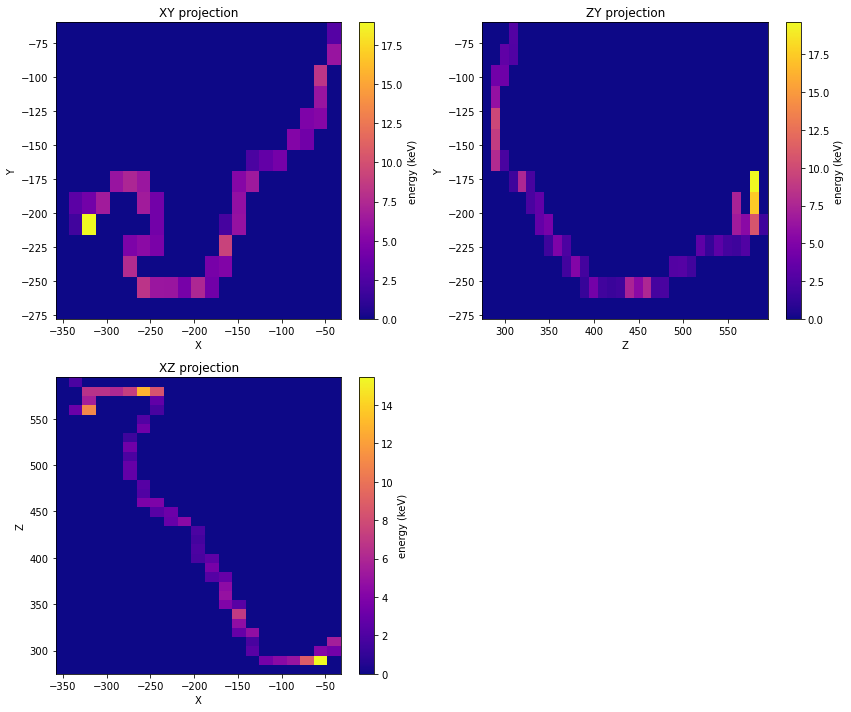

In [222]:
evtdeco   = evt[evt.decopred == 1]
enedeco   = 1e3* evtdeco.energy.values 
coorsdeco = get_coors(evtdeco)
event_display(coorsdeco, bins = bins, ene = enedeco);


In [225]:
graph = convert_to_graph(coorsdeco, bins, enedeco, nsides = 3)
componentes, longest_graph = graph_connectivity(graph)
_, longest_graph2 = graph_connectivity(longest_graph)

[(-1, -1, -1), (-1, -1, 0), (-1, -1, 1), (-1, 0, -1), (-1, 0, 0), (-1, 0, 1), (-1, 1, -1), (-1, 1, 0), (-1, 1, 1), (0, -1, -1), (0, -1, 0), (0, -1, 1), (0, 0, -1), (0, 0, 0), (0, 0, 1), (0, 1, -1), (0, 1, 0), (0, 1, 1), (1, -1, -1), (1, -1, 0), (1, -1, 1), (1, 0, -1), (1, 0, 0), (1, 0, 1), (1, 1, -1), (1, 1, 0), (1, 1, 1)]
Is graph conected?  True
Number of components: 1
Component 1: {(10, 4, 17), (13, 4, 13), (9, 8, 31), (9, 4, 19), (16, 9, 4), (19, 11, 2), (21, 13, 2), (8, 9, 31), (22, 15, 3), (16, 9, 5), (14, 7, 8), (10, 4, 18), (21, 12, 2), (16, 10, 3), (3, 8, 29), (7, 9, 31), (15, 9, 6), (13, 5, 11), (8, 6, 28), (7, 6, 26), (8, 4, 19), (15, 9, 5), (17, 10, 2), (15, 8, 6), (5, 8, 31), (7, 5, 24), (4, 8, 29), (15, 7, 7), (22, 16, 4), (15, 8, 7), (3, 7, 32), (4, 7, 30), (7, 6, 25), (9, 7, 31), (13, 5, 12), (14, 5, 10), (18, 10, 2), (6, 9, 31), (4, 7, 31), (14, 5, 11), (9, 6, 29), (7, 5, 23), (14, 6, 10), (8, 6, 27), (15, 7, 8), (20, 12, 2), (22, 15, 4), (9, 6, 30), (7, 5, 22), (12, 4

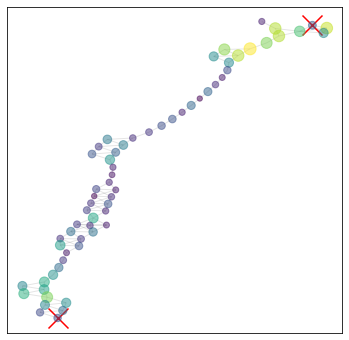

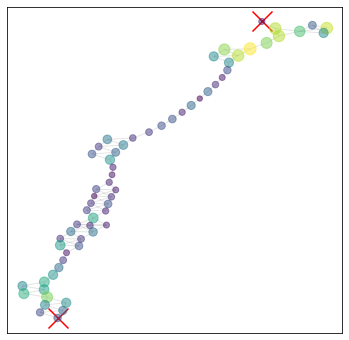

(((22, 16, 4), (3, 7, 32)), 42)

In [226]:
display_graph(graph)
display_graph(longest_graph)

Text(0.5, 1.0, 'Event 0 XY view')

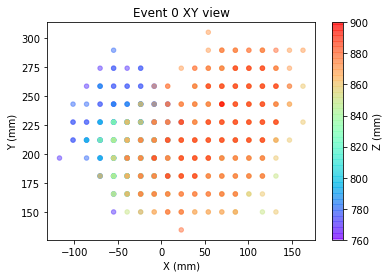

In [39]:
plt.scatter(coors[0], coors[1], c=coors[2], s=20, alpha = 0.5); plt.colorbar(label='Z (mm)'); plt.xlabel('X (mm)'); plt.ylabel('Y (mm)'); plt.title('Event 0 XY view')  